# UK Biobank — Non-Academic Impact

How UK Biobank research reaches beyond the academic literature. Three strands of
non-academic impact of the 20 years of UK Biobank publications:

**Sections**
1. **Setup** — imports, environment, the single shared formatting dictionary (`STYLE`)
2. **Data loading, cleaning & missing-data report** — the three raw sources, the
   nested (dict / list-of-dict) columns, and a quantified account of what is missing
   or dropped for each
3. **Patents** — patent counts by filing status & year, and patent topics by country (%),
   ported verbatim (same graphs) from `01_analysis_01_patents_analysis_modularized.ipynb`
4. **Clinical trials** — *moved to its own notebook* `…_03_clinic_trials.ipynb` (deeper CT + funding-impact analysis)
5. **Policy documents** — what topics, and which countries publish the policy that cites UKB

> **Modularisation note.** As in the authorship notebook, functions are written here
> while the analysis is still being developed, kept *pure* (they take data + the shared
> `STYLE` dict and return objects / figures) so that, as a final step, they can be lifted
> into `src/utils/nonacademic_utils.py` — mirroring the `utils/patent_utils.py` pattern.
> The **patent** section deliberately calls `utils/patent_utils.py` directly so its two
> figures are byte-for-byte the same as in the modularized patents notebook.

## 1. Setup

Imports, working directory, and the **single shared formatting dictionary** (`STYLE`)
that every visualisation in this notebook reads from — the four-colour palette, figure
sizes, font sizes, dpi. The patent figures (§3) are the one exception: they reuse the
`patent_utils` plotters unchanged so they match the original patents notebook exactly.

In [ ]:
import os
import sys
import ast
import json
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

# Make `src` importable and anchor all paths on the repo root, regardless of the
# directory this notebook is launched from (repo root, src/, or src/data_analysis/).
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "utils").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import shared_paths as P
P.bootstrap()

# Reuse the patent analysis helpers (country/topic/plotting code).
from utils import shared_patent_utils as patent


In [ ]:
# =============================================================================
# SHARED FORMATTING DICTIONARY  -- every figure reads from this
# =============================================================================
# The palette, figure sizes, font sizes, semantic colour roles and output directory
# live in universal_settings.yml at the repo root, section style.notebooks.04_non_academic_00_all.
# load_style merges the shared `base` with this notebook's overrides, resolves the
# semantic roles (c_accent, c_gold, c_green, c_primary) against the palette, registers the result for
# savefig()/extended_palette() and pushes it into rcParams — everything the STYLE
# literal used to do here, minus the drift between notebooks.
from utils.shared_style import apply_style, extended_palette, load_style, savefig, use_style
STYLE = load_style("04_non_academic_00_all")

print("STYLE ready — palette:", STYLE["colors"])


## 2. Data loading, cleaning & missing-data report

Three raw sources, all exported from Dimensions, one per impact strand:

| strand | file | rows |
|---|---|---|
| patents | `data/non_academic/patent/patents_detailed.csv` | ~ |
| clinical trials | `data/non_academic/clinic_trials/clinical_trials.csv` | 151 |
| policy documents | `data/non_academic/policy_documents.csv` | 348 |


**Nested columns.** Several fields are **not** flat values — they are stringified Python
objects that must be `ast.literal_eval`-parsed before use:

* *list of strings* — `conditions`, `mesh_terms`, `active_years`
* *list of dicts* (`{id, name}`) — `category_for_2020`, `category_hrcs_hc`,
  `category_rcdc`, `funder_countries`
* *list of dicts* (full org records) — `research_orgs`, `funders`, `researchers`
* *list of lists* — `investigators` (`[name, degree, role, org, ...]`)
* *single dict* — policy `publisher_org`, `publisher_org_country`, `publisher_org_city`

**Fields of Research (FOR) — one splitter, L2 + L4 columns.** `category_for_2020` (and the
byte-identical `category_for` — the two are equal in **100%** of rows in all three files,
so we keep only `category_for_2020`) is an unordered multi-label set of `{id, name}` where
each name begins with a numeric code: **2-digit = L2 division** (`42 Health Sciences`),
**4-digit = L4 field** (`4203 Health Services and Systems`). Mirroring the authorship
notebook, one function `split_for_levels` separates the two levels, and `add_for_columns`
attaches them as **two list columns `for_l2` / `for_l4`** to every dataframe that carries
the source column (so each file ends with the two extra columns, not a nested dict — lists
are directly explodable / countable downstream).

The helpers below parse everything safely (never raising: a malformed / `NaN` cell becomes
an empty list/dict), and the **full** missing-data report (every column) quantifies the cost.

In [ ]:
from utils.shared_showcase import parse_listcol, parse_dictcol, item_names, count_items
# =============================================================================
# PARSING HELPERS — safe, never-raising parsers for the nested columns
# =============================================================================
# ---- Fields of Research (FOR, 2020 ANZSRC) L2/L4 splitter -------------------
# Shared implementation: src/utils/for_utils.py. It resolves the FOR column itself —
# newer Dimensions exports renamed `category_for_2020` -> `category_for` (same taxonomy),
# and the old local copy SILENTLY returned the frame unchanged when the column was
# missing, producing no for_l2/for_l4 at all. The shared version raises instead.
from utils.shared_for import split_for_levels, add_for_columns, resolve_for_column


In [ ]:
# =============================================================================
# LOAD the three raw sources  (all three, so the missing report below covers each)
# =============================================================================
CT_PATH     = P.CT_CSV
POLICY_PATH = P.POLICY_CSV
PATENT_PATH = P.PATENTS_DETAILED

df_ct     = pd.read_csv(CT_PATH)
df_policy = pd.read_csv(POLICY_PATH)
df_patent = pd.read_csv(PATENT_PATH)      # reused unchanged by the §3 patent pipeline

print(f"Clinical trials : {df_ct.shape[0]:>5} rows x {df_ct.shape[1]} cols")
print(f"Policy documents: {df_policy.shape[0]:>5} rows x {df_policy.shape[1]} cols")
print(f"Patents         : {df_patent.shape[0]:>5} rows x {df_patent.shape[1]} cols")

# FOR L2/L4 split — ONE function, applied to every file that carries category_for_2020.
# Each df gains two list columns: for_l2 (divisions) and for_l4 (fields).
for _d in (df_ct, df_policy, df_patent):
    add_for_columns(_d, "category_for_2020")

# Clinical trials: start_year (when the trial began) + active_years as a real list.
df_ct["start_date_parsed"] = pd.to_datetime(df_ct["start_date"], errors="coerce")
df_ct["start_year"] = df_ct["start_date_parsed"].dt.year
df_ct["active_years_list"] = df_ct["active_years"].apply(parse_listcol)

# Policy: pull the flat country / city name out of the single-dict columns.
df_policy["publisher_country"] = df_policy["publisher_org_country"].apply(
    lambda x: parse_dictcol(x).get("name"))
df_policy["publisher_name"] = df_policy["publisher_org"].apply(
    lambda x: parse_dictcol(x).get("name"))

# Clinical-trial COUNTRY coverage (research-org basis) — is it complete? Report openly.
_ct_has_country = df_ct["research_orgs"].apply(
    lambda x: any(isinstance(d, dict) and d.get("country_name") for d in parse_listcol(x)))
print(f"\nCT trials with >=1 research-org country: {_ct_has_country.sum()}/{len(df_ct)} "
      f"({100*_ct_has_country.mean():.0f}%)  — {int((~_ct_has_country).sum())} trials have none")
print("CT start years :", int(df_ct["start_year"].min()), "-", int(df_ct["start_year"].max()))
print("Policy years   :", int(df_policy["year"].min()), "-", int(df_policy["year"].max()))

### Missing-data report (quantified, **every column**)

Computed live from the data so it never drifts. The report auto-detects each column's
structure (flat / list / dict) and, for the nested ones, reports how many rows parse to a
**non-empty** value — the honest denominator for any analysis built on that column. Sorted
most-missing first. Shown for **all three** files (patents included).

In [5]:
def _col_kind(series):
    """Guess a column's structure from its first non-null value: flat / list / dict."""
    for v in series.dropna():
        if isinstance(v, list):
            return "list"
        if isinstance(v, dict):
            return "dict"
        if isinstance(v, str):
            s = v.strip()
            if s.startswith("["):
                return "list"
            if s.startswith("{"):
                return "dict"
        return "flat"
    return "empty"


def missing_report(df, cols=None):
    """FULL per-column missing / parse report over every column (or a subset `cols`).
    For nested (list/dict) columns also reports how many rows parse to a NON-EMPTY
    structure. Returns a tidy frame sorted by %_missing (descending)."""
    n = len(df)
    cols = list(df.columns) if cols is None else cols
    rows = []
    for c in cols:
        kind = _col_kind(df[c])
        miss = int(df[c].isna().sum())
        if kind == "list":
            ne = int(df[c].apply(lambda x: len(parse_listcol(x)) > 0).sum())
        elif kind == "dict":
            ne = int(df[c].apply(lambda x: len(parse_dictcol(x)) > 0).sum())
        else:
            ne = n - miss
        rows.append((c, kind, miss, round(100 * miss / n, 1), ne, round(100 * ne / n, 1)))
    return (pd.DataFrame(rows, columns=["column", "kind", "n_missing", "%_missing",
                                        "n_nonempty", "%_nonempty"])
            .sort_values("%_missing", ascending=False, ignore_index=True))


for _name, _df in [("CLINICAL TRIALS", df_ct), ("POLICY DOCUMENTS", df_policy),
                   ("PATENTS", df_patent)]:
    print(f"\n{'='*72}\n{_name}   (n = {len(_df)},  {_df.shape[1]} columns)\n{'='*72}")
    with pd.option_context("display.max_rows", None):
        display(missing_report(_df))


CLINICAL TRIALS   (n = 151,  48 columns)


,column,kind,n_missing,%_missing,n_nonempty,%_nonempty
0,associated_grant_ids,list,143,94.7,8,5.3
1,phase,flat,141,93.4,10,6.6
2,altmetric,flat,132,87.4,19,12.6
3,category_icrp_cso,list,123,81.5,28,18.5
4,category_icrp_ct,list,113,74.8,38,25.2
5,acronym,flat,67,44.4,84,55.6
6,study_maximum_age,flat,63,41.7,88,58.3
7,funders,list,56,37.1,95,62.9
8,funder_countries,list,56,37.1,95,62.9
9,category_hrcs_rac,list,46,30.5,105,69.5



POLICY DOCUMENTS   (n = 348,  25 columns)


,column,kind,n_missing,%_missing,n_nonempty,%_nonempty
0,category_icrp_cso,list,312,89.7,36,10.3
1,category_icrp_ct,list,299,85.9,49,14.1
2,category_hrcs_rac,list,261,75.0,87,25.0
3,publisher_org_state,dict,249,71.6,99,28.4
4,category_bra,list,248,71.3,100,28.7
5,category_hra,list,234,67.2,114,32.8
6,category_hrcs_hc,list,204,58.6,144,41.4
7,category_rcdc,list,98,28.2,250,71.8
8,category_for,list,7,2.0,341,98.0
9,category_for_2020,list,7,2.0,341,98.0



PATENTS   (n = 513,  58 columns)


,column,kind,n_missing,%_missing,n_nonempty,%_nonempty
0,associated_grant_ids,list,487,94.9,26,5.1
1,federal_support,list,486,94.7,27,5.3
2,funder_countries,list,486,94.7,27,5.3
3,funders,list,486,94.7,27,5.3
4,researchers,list,479,93.4,34,6.6
5,category_icrp_cso,list,477,93.0,36,7.0
6,category_icrp_ct,list,456,88.9,57,11.1
7,additional_filters,list,408,79.5,105,20.5
8,category_hra,list,399,77.8,114,22.2
9,category_hrcs_rac,list,346,67.4,167,32.6


**Data-handling decisions (read before trusting a count).**

* **Nested cells never crash an analysis** — `parse_listcol` / `parse_dictcol` turn any
  malformed or `NaN` cell into an empty list/dict, so a missing value simply contributes
  nothing rather than dropping the whole row.
* **Frequency counts are "documents containing X", not raw mentions** — `count_items`
  de-duplicates within a row, so a trial listing *Cardiovascular* twice still counts once.
* **Clinical trials — `phase` is 93% missing** (most are observational or non-phased), so
  we do **not** analyse phase. `mesh_terms` (8% missing) is preferred over free-text
  `conditions` for the "what" view because it is a controlled vocabulary.
* **Clinical trials — "who/where" uses `research_orgs`** (4% missing). Country coverage is
  **near-complete but not total: 145/151 trials (96%)** resolve to ≥1 research-org country;
  the remaining **6** carry no org country and are simply absent from the country chart
  (printed in the load cell above). Each country is counted **once per trial**;
  `funders`/`funder_countries` are 37% missing and used only as a secondary view.
* **Clinical trials — "when" uses `start_year`** (0% missing, all 151 parse). We avoid
  `active_years` for the main timeline because it projects to 2057 (planned end dates)
  and would exaggerate recent activity.
* **Clinical trials — status** is analysed both at the raw 9-level `overall_status` and via
  a coarse **lifecycle stage** (`status_stage`: Planned / Ongoing / Completed / Stopped
  early / Unknown), each split by interventional vs. observational `study_type`.
* **Policy — "what" uses FOR L2** (`for_l2`, from `category_for_2020`): only **7/348 (2%)**
  documents are uncoded, far better than `category_hrcs_hc` (**59% missing**), so we drop
  HRCS from the main topic view. `category_rcdc` (28% missing) is shown **separately** as a
  word cloud (finer-grained research areas, better suited to a cloud than a bar).
* **Policy — the flat `publisher_country`** is extracted from the `publisher_org_country`
  dict (0% missing) for the country-level "where" view.

## 3. Patents

Ported from `01_analysis_01_patents_analysis_modularized.ipynb`. Only the pipeline that
feeds the **two requested figures** is reproduced here; every other patent analysis stays
in that notebook. The figures call the **same `patent_utils` functions with the same
arguments**, so they are identical to the originals.

1. **Patent counts by filing status and publication year** (`plot_filing_status_over_time`
   on `legal_status_replaced`).
2. **Patent topics by country (%)** — a normalised country×topic heatmap plus the
   dominant topic per country (`analyze_country_topics` → `plot_country_topic_heatmap` /
   `plot_country_dominant_topics`).

In [6]:
# --- Patent pipeline (faithful to the modularized notebook, trimmed to the two figures) ---
# df_patent was loaded in §2 (patents_detailed.csv). We do NOT re-read it here.
print(f"Patents: {len(df_patent)}")

# publication year (needed by the filing-status figure)
df_patent["publication_date"] = pd.to_datetime(df_patent["publication_date"], errors="coerce")
df_patent["publication_year"] = df_patent["publication_date"].dt.year
df_patent["year"] = df_patent["publication_year"]

# assignee -> country (aggressive/low-confidence mode, exactly as in notebook 01)
df_with_iso = patent.assign_assignee_countries_with_iso(
    df_patent,
    assignee_col="assignees",
    assignee_names_col="assignee_names",
    use_low_confidence=True,
    primary_pick="most_common",
)

# collapse FOR categories to top-level topics + build the code->label map
df_with_iso["top_level_topics"] = (
    df_with_iso["category_for"].apply(patent.safe_parse_category).apply(patent.collapse_to_top_level))

topcode_to_label = {}
for topics in df_with_iso["top_level_topics"]:
    if isinstance(topics, list):
        for code, label in topics:
            if code and label and code not in topcode_to_label:
                topcode_to_label[code] = label

print(f"Patents with country info: {df_with_iso['assignee_countries'].notna().sum()}")
print(f"Distinct top-level topics: {len(topcode_to_label)}")

Patents: 513


Patents with country info: 513
Distinct top-level topics: 12


### 3.1 Patent counts by filing status and publication year

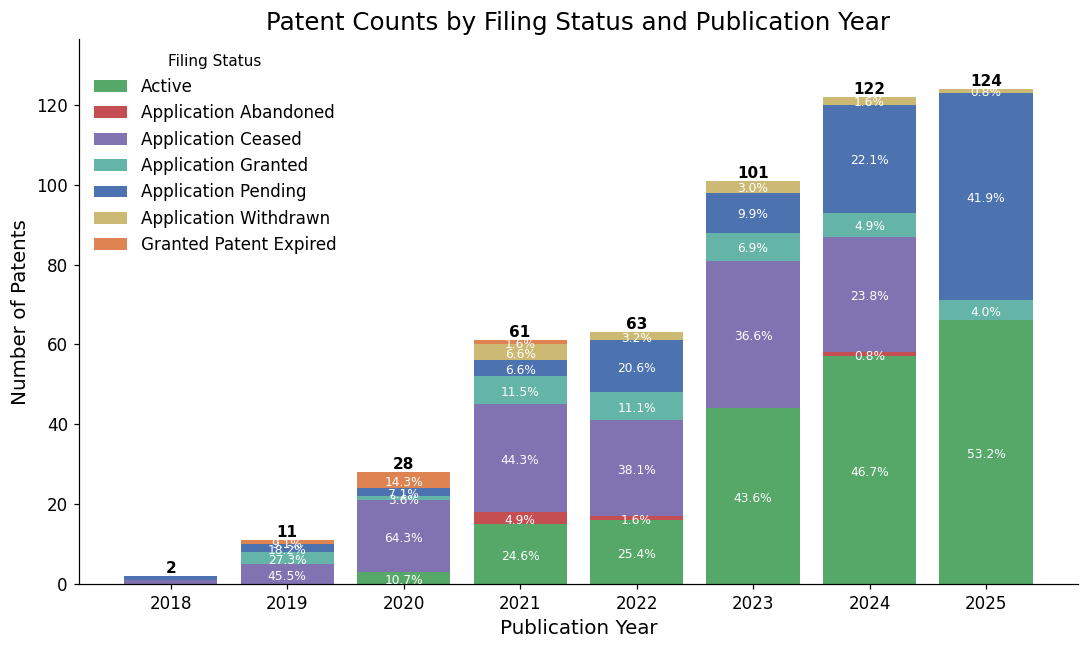

In [7]:
# Same call as notebook 01, cell 21 — 'legal_status_replaced' is derived inside the
# function from 'legal_status'. Identical figure.
col = "legal_status_replaced"
patent.plot_filing_status_over_time(df_with_iso, col, figsize=(10, 6), savefigure=False)
plt.show()

### 3.2 Patent topics by country (%)

Countries with topic data: 24


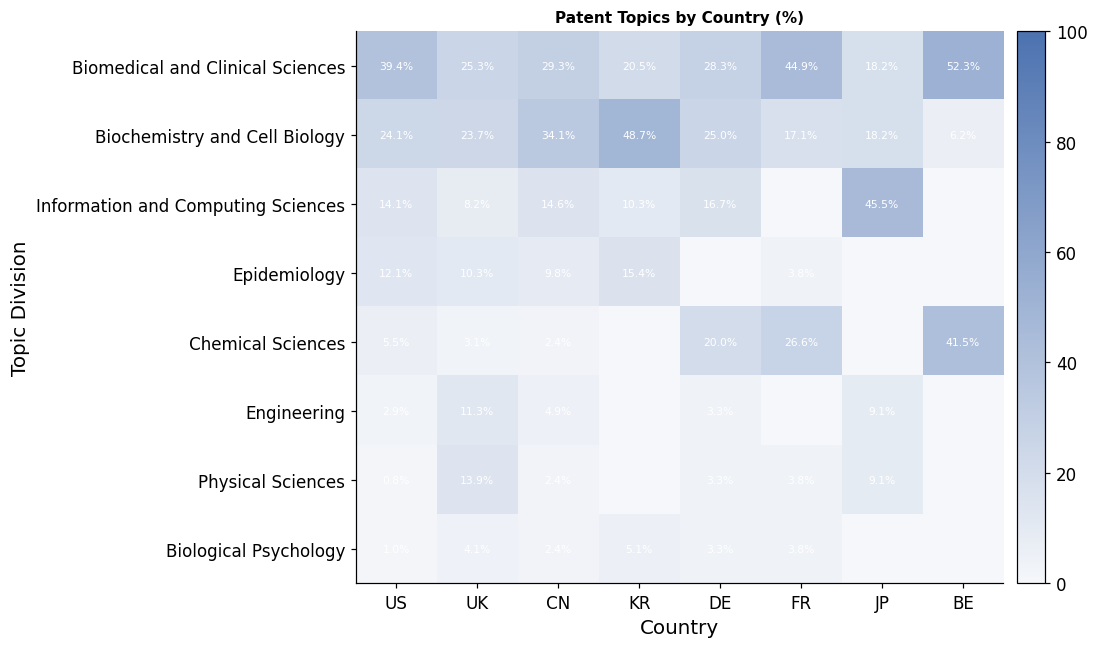

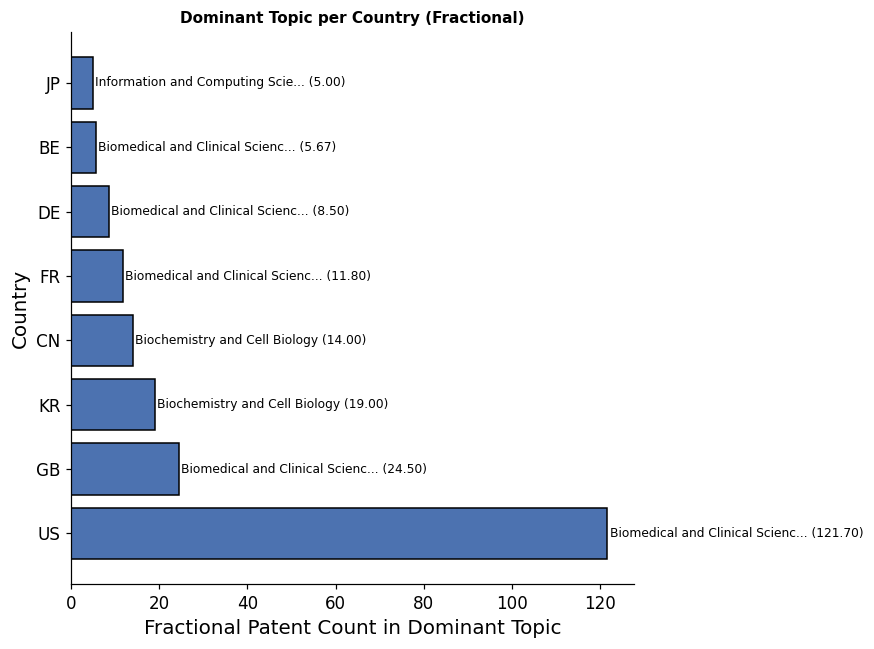

In [8]:
# Same call as notebook 01, cell 20 — fractional country x topic matrix, then the
# normalised heatmap and the dominant-topic-per-country bar. Identical figures.
(country_topic_rows, pivot_country_topic, top_countries, top_topic_codes,
 country_counter, topic_counter_frac) = patent.analyze_country_topics(
    df_with_iso,
    topics_col="top_level_topics",
    country_col="assignee_countries",
    code_to_label=topcode_to_label,
    top_countries=8,
    top_topics=8,
)

if not country_topic_rows.empty:
    topic_by_country = (
        country_topic_rows.groupby(["country", "topic_code", "topic_label"])["weight"]
        .sum().reset_index(name="count"))
    print(f"Countries with topic data: {topic_by_country['country'].nunique()}")

    patent.plot_country_topic_heatmap(
        pivot_country_topic, code_to_label=topcode_to_label, figsize=(10, 6), savefile=None)

    patent.plot_country_dominant_topics(
        topic_by_country, top_countries=top_countries,
        code_to_label=topcode_to_label, figsize=(8, 6), savefile=None)
else:
    print("No country-topic data available for visualization.")

## 4. Clinical trials — moved

The clinical-trials analysis has moved to its own, deeper notebook:
[`01_analysis_05_non_academic_impact_03_clinic_trials.ipynb`](01_analysis_05_non_academic_impact_03_clinic_trials.ipynb).

It reuses **this notebook's setup, `STYLE`, and data-cleaning rules** verbatim and expands the CT view: diseases (MeSH raw + fractional, and a free-text `conditions` word cloud), the aggregated lifecycle stage, recruitment size, organisations by country **and sector** (academia vs. industry), and — the impact core — the **UK Biobank papers the trials cite** (matched from `df_dimensions`, saved to `data/non_academic/clinic_trials/ct_ukbb_papers.csv`).

> `df_ct` is still loaded and reported in §2 above as part of the cross-strand overview; only the analysis figures moved.

In [9]:
# ---- Shared STYLE-driven plotting primitives (used by the Policy section below) ----
def plot_hbar(counts, title, xlabel, style=STYLE, color=None, ax=None,
              annotate=True, pct_of=None, name="hbar"):
    """Horizontal bar chart of a pre-sorted count Series (largest at the top).
    pct_of : if given (a denominator N), annotate each bar as a % of N as well."""
    color = color or style["c_primary"]
    counts = counts.sort_values(ascending=True)          # barh -> largest on top
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(style["figsize_small"][0],
                                        max(3.5, 0.45 * len(counts) + 1)))
    else:
        fig = ax.figure
    bars = ax.barh(counts.index.astype(str), counts.values,
                   color=color, edgecolor=style["edgecolor"], linewidth=0.6)
    if annotate:
        for b, v in zip(bars, counts.values):
            lab = f"{int(v)}" + (f"  ({100*v/pct_of:.0f}%)" if pct_of else "")
            ax.text(v + max(counts.values) * 0.01, b.get_y() + b.get_height()/2,
                    lab, va="center", fontsize=style["annot_fs"])
    ax.set_title(title, fontsize=style["title_fs"], fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=style["label_fs"])
    ax.margins(x=0.12)
    if own_fig:
        fig.tight_layout(); savefig(fig, name, style)
    return fig, ax


def plot_bar_over_time(counts_by_year, title, ylabel, style=STYLE, color=None,
                       ax=None, name="over_time"):
    """Simple bar chart of a count-per-year Series (index = year)."""
    color = color or style["c_green"]
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=style["figsize_small"])
    else:
        fig = ax.figure
    ax.bar(counts_by_year.index.astype(int), counts_by_year.values,
           color=color, edgecolor=style["edgecolor"], linewidth=0.6)
    for x, v in zip(counts_by_year.index.astype(int), counts_by_year.values):
        if v > 0:
            ax.text(x, v, f"{int(v)}", ha="center", va="bottom",
                    fontsize=style["annot_fs"])
    ax.set_title(title, fontsize=style["title_fs"], fontweight="bold")
    ax.set_xlabel("Year", fontsize=style["label_fs"])
    ax.set_ylabel(ylabel, fontsize=style["label_fs"])
    if own_fig:
        fig.tight_layout(); savefig(fig, name, style)
    return fig, ax


## 5. Policy documents

**348** policy documents that cite UK Biobank research. Four views:

* **What (divisions)** — which Fields of Research? (`for_l2`, from `category_for_2020` —
  only 2% uncoded, so it replaces the 59%-missing `category_hrcs_hc`)
* **What (research areas)** — a **word cloud** of the finer-grained `category_rcdc`
  labels, kept **separate** from the divisions above
* **Where** — which countries' bodies publish this policy? (`publisher_country`,
  extracted from the `publisher_org_country` dict — country level)
* **When** — how has policy uptake grown? (`year`)

Same `STYLE`-driven primitives as §4 (`plot_hbar`, `plot_bar_over_time`), plus a palette-
coloured `plot_rcdc_wordcloud`.

### 5.1 What — research divisions (Fields of Research, L2)

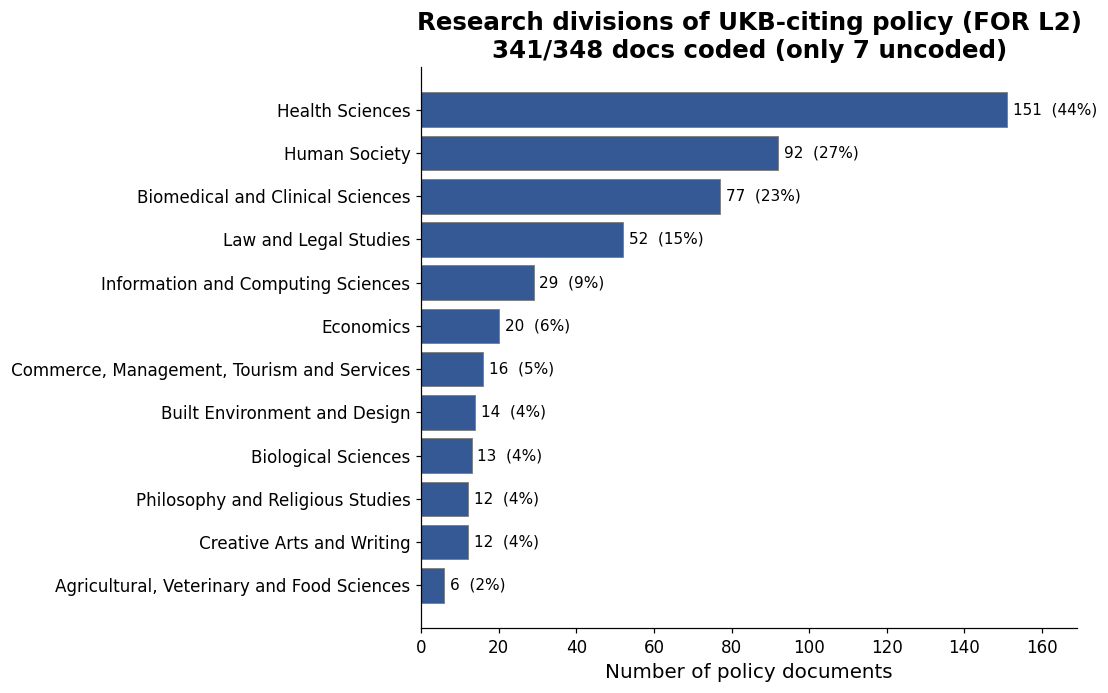

,n_docs
Health Sciences,151
Human Society,92
Biomedical and Clinical Sciences,77
Law and Legal Studies,52
Information and Computing Sciences,29
Economics,20
"Commerce, Management, Tourism and Services",16
Built Environment and Design,14
Biological Sciences,13
Creative Arts and Writing,12


In [10]:
n_for = int((df_policy["for_l2"].apply(len) > 0).sum())
for_top = count_items(df_policy["for_l2"], top=12)
fig, ax = plot_hbar(
    for_top, f"Research divisions of UKB-citing policy (FOR L2)\n"
             f"{n_for}/{len(df_policy)} docs coded (only {len(df_policy)-n_for} uncoded)",
    "Number of policy documents", color=STYLE["c_primary"],
    pct_of=n_for, name="policy_for_l2")
plt.show()
for_top.to_frame("n_docs")

### 5.2 What — research areas (RCDC) word cloud

A **separate**, finer-grained view: the `category_rcdc` research-area labels as a word
cloud (word size ∝ number of documents), coloured from the project palette. RCDC is
28% missing (reported in the title); the cloud is intentionally kept apart from the FOR
divisions above because RCDC is a much longer, more specific vocabulary.

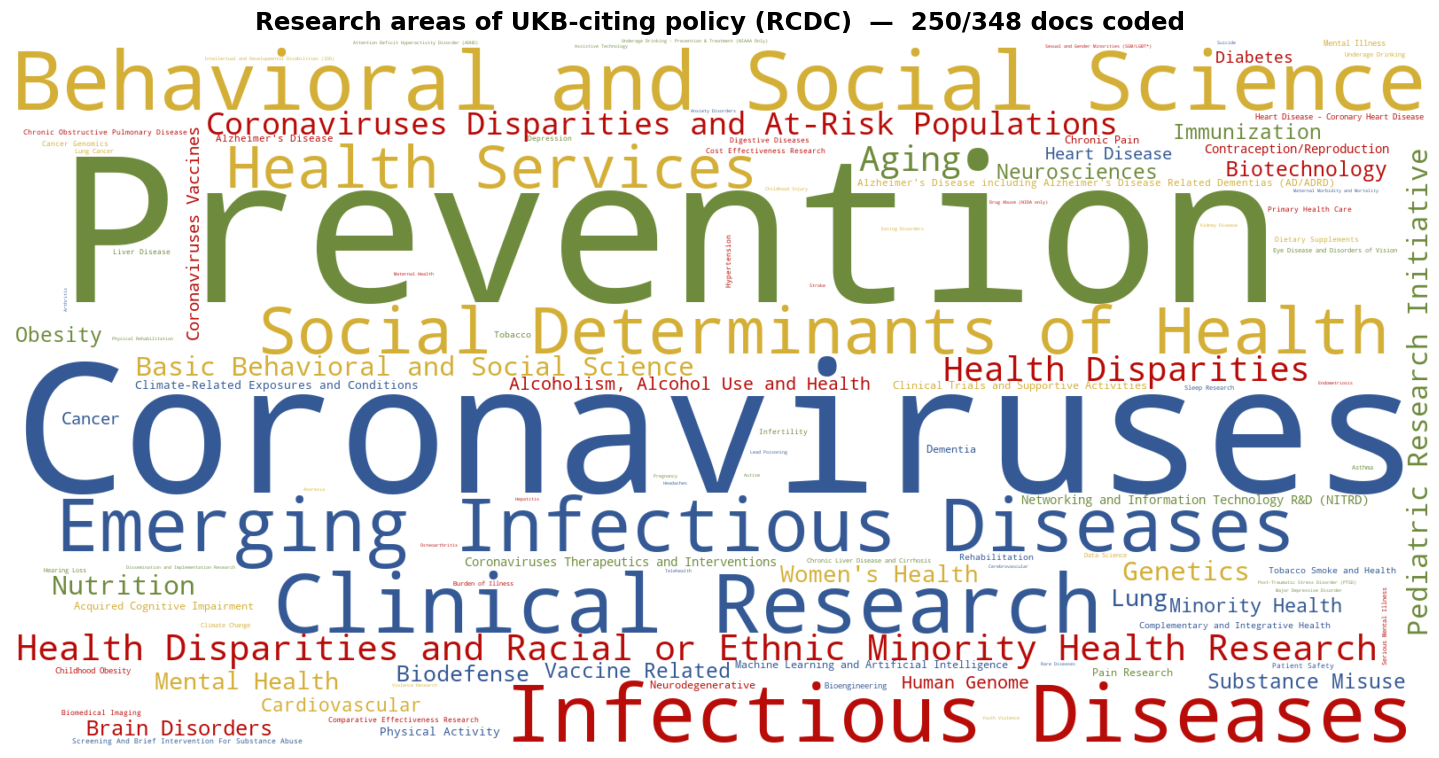

Top RCDC areas: Prevention (92), Coronaviruses (72), Behavioral and Social Science (70), Clinical Research (70), Infectious Diseases (67), Emerging Infectious Diseases (67), Social Determinants of Health (53), Health Services (43), Health Disparities and Racial or Ethnic Minority Health Research (41), Aging (39)


In [11]:
def plot_rcdc_wordcloud(df, col="category_rcdc", style=STYLE, max_words=120,
                        name="policy_rcdc_wordcloud"):
    """Word cloud of RCDC research-area labels (frequency = #documents containing it),
    coloured by sampling the project palette so it matches the rest of the notebook."""
    import random
    from wordcloud import WordCloud
    freqs = count_items(df[col]).to_dict()
    palette = style["colors"]

    def _color(*args, **kwargs):
        return random.choice(palette)

    wc = WordCloud(width=1600, height=800, background_color="white",
                   prefer_horizontal=0.95, color_func=_color, max_words=max_words,
                   collocations=False, random_state=42).generate_from_frequencies(freqs)
    n_cod = int((df[col].apply(lambda x: len(parse_listcol(x)) > 0)).sum())
    fig, ax = plt.subplots(figsize=style["figsize_wide"])
    ax.imshow(wc, interpolation="bilinear"); ax.axis("off")
    ax.set_title(f"Research areas of UKB-citing policy (RCDC)  —  "
                 f"{n_cod}/{len(df)} docs coded",
                 fontsize=style["title_fs"], fontweight="bold")
    fig.tight_layout(); savefig(fig, name, style)
    return fig, ax, freqs

_, _, rcdc_freqs = plot_rcdc_wordcloud(df_policy)
plt.show()
print("Top RCDC areas:", ", ".join(f"{k} ({v})"
      for k, v in sorted(rcdc_freqs.items(), key=lambda kv: -kv[1])[:10]))

### 5.3 Where — publisher country

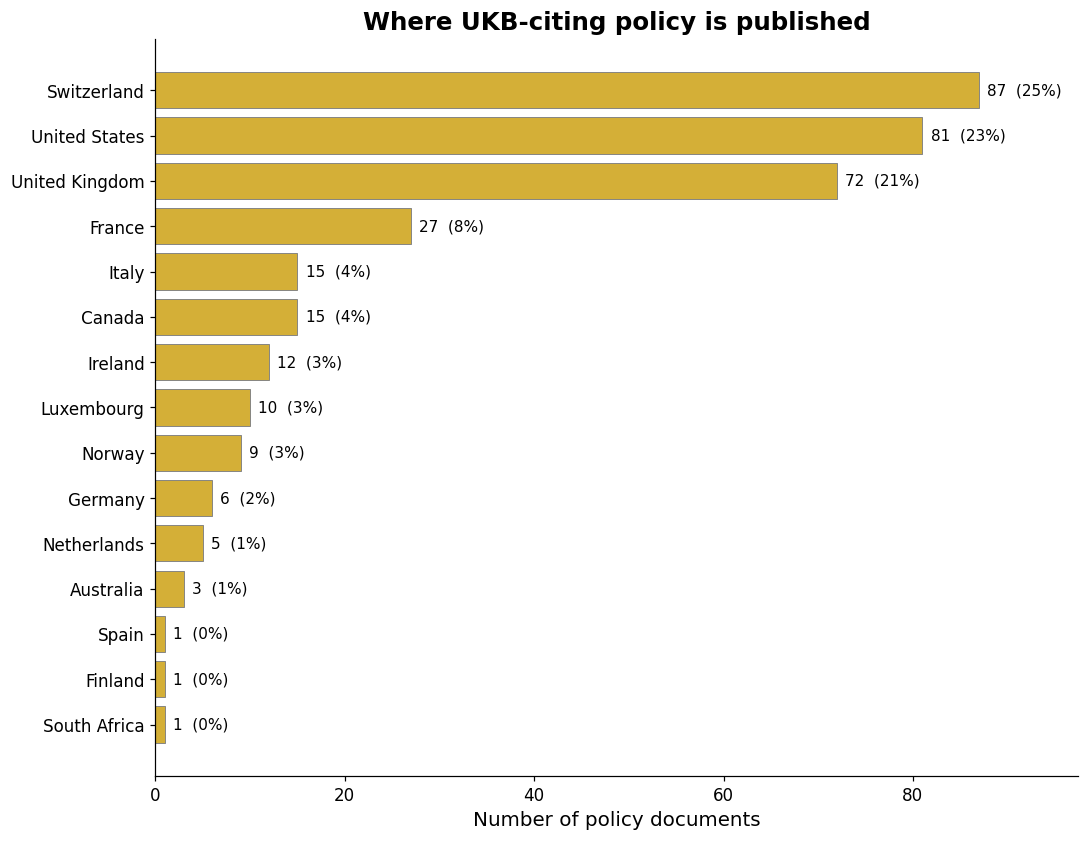

In [12]:
country_counts = df_policy["publisher_country"].value_counts().head(15)
fig, ax = plot_hbar(country_counts, "Where UKB-citing policy is published",
                    "Number of policy documents", color=STYLE["c_gold"],
                    pct_of=len(df_policy), name="policy_countries")
plt.show()

### 5.4 When — policy documents over time

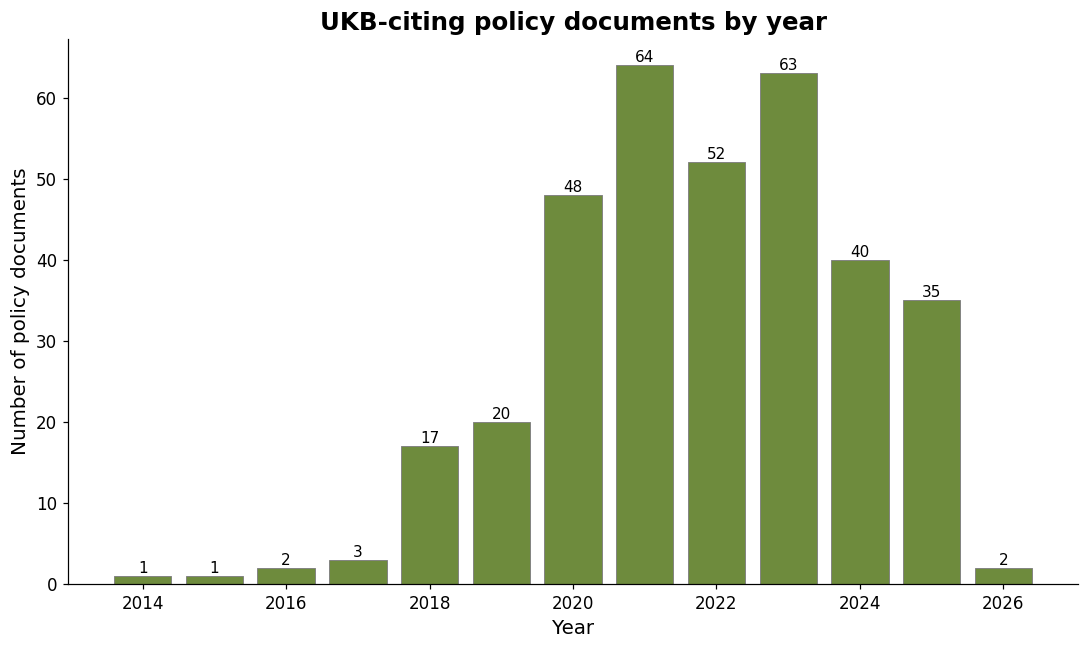

In [13]:
year_counts = df_policy.groupby("year").size()
year_counts = year_counts.reindex(
    range(int(year_counts.index.min()), int(year_counts.index.max()) + 1), fill_value=0)
fig, ax = plot_bar_over_time(year_counts, "UKB-citing policy documents by year",
                             "Number of policy documents", color=STYLE["c_green"],
                             name="policy_over_time")
plt.show()

### 5.5 Combined policy panel

The FOR divisions, publisher country, and yearly trend in one figure, reusing the section
draw routines. (The RCDC word cloud stays standalone — §5.2.)

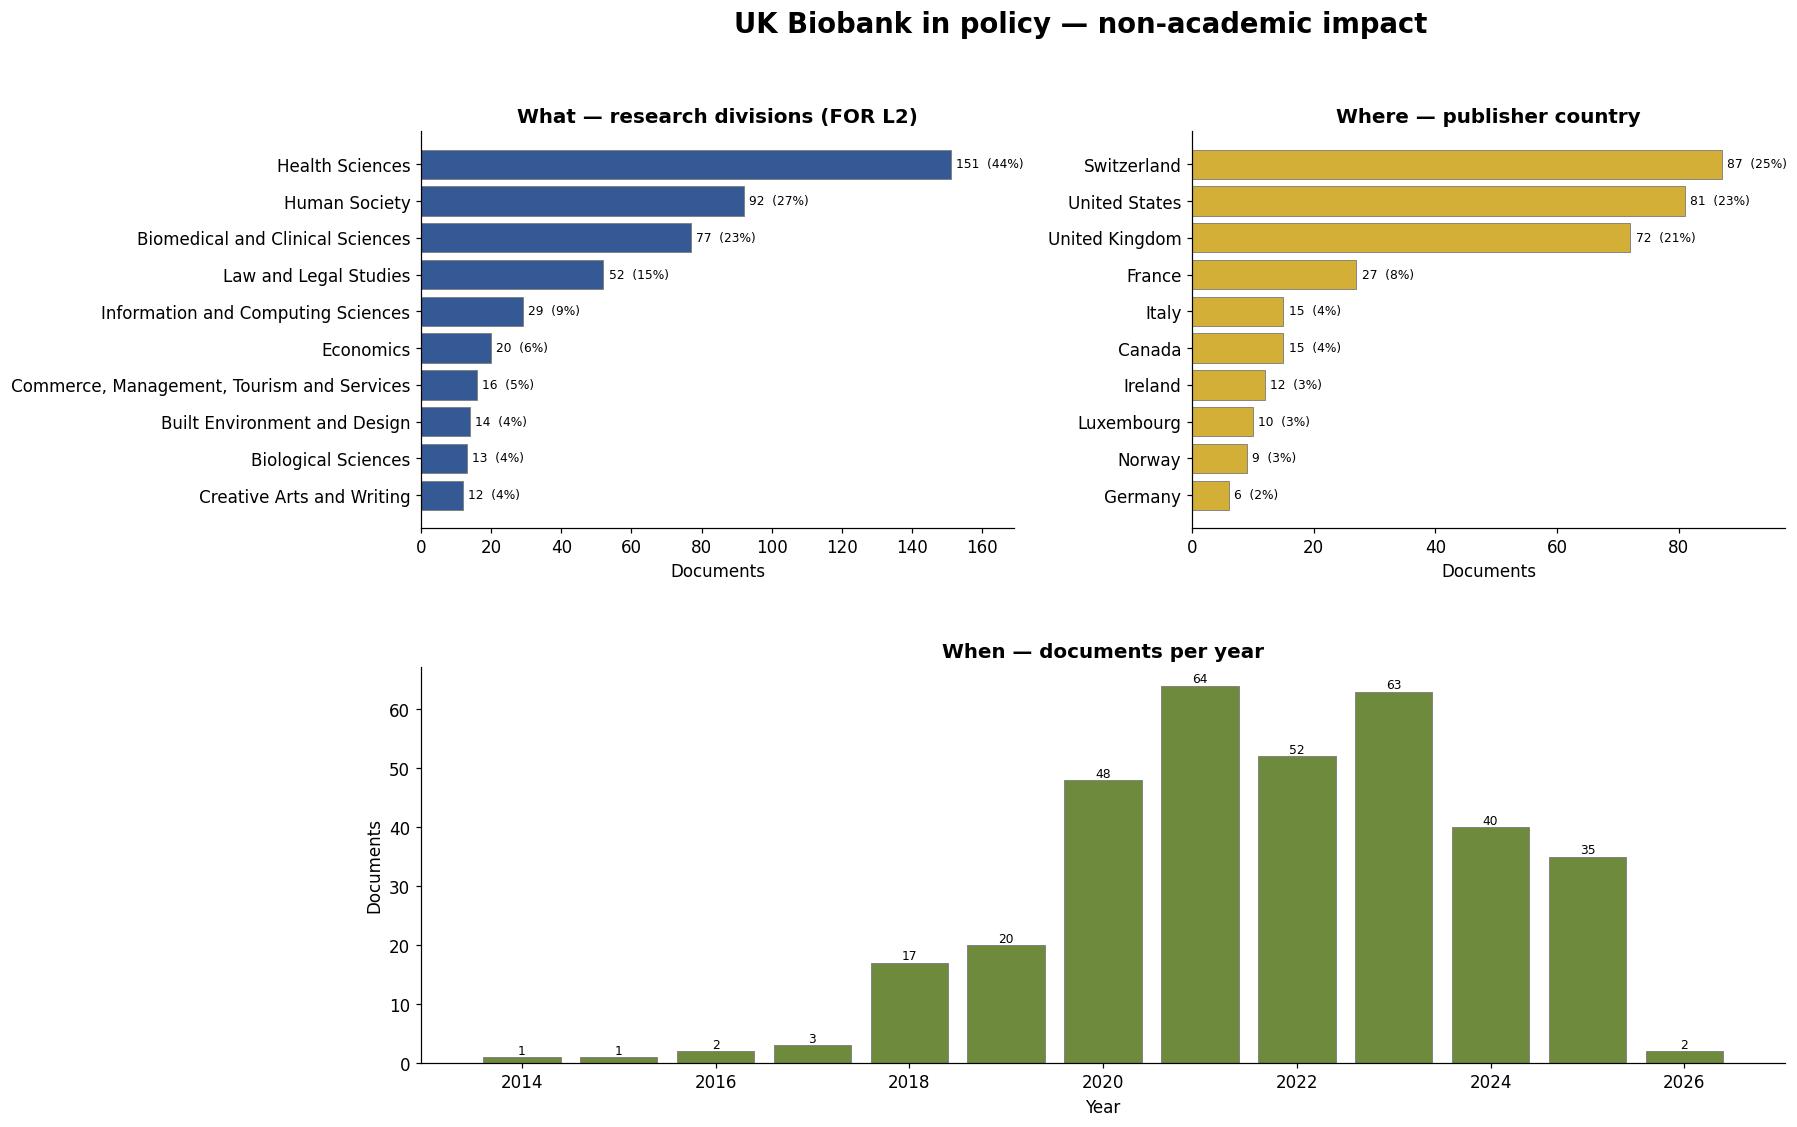

In [14]:
def plot_policy_panel(df, style=STYLE, name="policy_combined"):
    cstyle = {**style, "title_fs": 13, "label_fs": 11, "tick_fs": 9,
              "annot_fs": 8, "legend_fs": 9}
    fig = plt.figure(figsize=(16, 11))
    gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)
    ax_for  = fig.add_subplot(gs[0, 0])
    ax_ctry = fig.add_subplot(gs[0, 1])
    ax_time = fig.add_subplot(gs[1, :])

    n_for = int((df["for_l2"].apply(len) > 0).sum())
    plot_hbar(count_items(df["for_l2"], top=10),
              "What — research divisions (FOR L2)", "Documents",
              style=cstyle, color=style["c_primary"], pct_of=n_for, ax=ax_for)
    plot_hbar(df["publisher_country"].value_counts().head(10),
              "Where — publisher country", "Documents",
              style=cstyle, color=style["c_gold"], pct_of=len(df), ax=ax_ctry)
    yc = df.groupby("year").size()
    yc = yc.reindex(range(int(yc.index.min()), int(yc.index.max()) + 1), fill_value=0)
    plot_bar_over_time(yc, "When — documents per year", "Documents",
                       style=cstyle, color=style["c_green"], ax=ax_time)
    fig.suptitle("UK Biobank in policy — non-academic impact",
                 fontsize=style["title_fs"] + 2, fontweight="bold")
    savefig(fig, name, style)
    return fig

plot_policy_panel(df_policy)
plt.show()

## Next step — modularisation

Once the analysis is settled, lift the function cells above into
`src/utils/nonacademic_utils.py` (one module, mirroring `utils/patent_utils.py`) and
replace them here with:

```python
from utils import nonacademic_utils as na
```

The functions are already pure and `STYLE`-driven, so the move is mechanical:
`parse_listcol`, `parse_dictcol`, `item_names`, `count_items`, `split_for_levels`,
`add_for_columns`, `_col_kind`, `missing_report`, `plot_hbar`, `plot_grouped_status`,
`plot_bar_over_time`, `ct_country_counts`, `ct_org_counts`, `plot_rcdc_wordcloud`,
`plot_ct_panel`, `plot_policy_panel` — plus the `STATUS_STAGE`/`STAGE_ORDER` maps and the
`STYLE` dict / `apply_style` / `extended_palette` / `savefig` helpers.

The **patent** section already delegates to `utils/patent_utils.py`, so it needs no
further modularisation — it only needs the short driver cells kept here.